# MAE 263F – Homework 3

Robotic control of an elastic beam.

This notebook is based on your Homework 2 code, with an added HW3 main block at the end.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output # Only for iPython

#Helper function

In [22]:
def crossMat(a):
    """
    Returns the cross product matrix of vector 'a'.

    Parameters:
    a : np.ndarray
        A 3-element array representing a vector.

    Returns:
    A : np.ndarray
        The cross product matrix corresponding to vector 'a'.
    """
    A = np.array([[0, -a[2], a[1]],
                  [a[2], 0, -a[0]],
                  [-a[1], a[0], 0]])

    return A

#Gradient and Hessian of elastic energies

In [23]:
def gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the derivative of bending energy E_k^b with respect to
    x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dF : np.ndarray
        Derivative of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0.0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Gradient of bending energy
    dkappa = kappa1 - kappaBar
    dF = gradKappa * EI * dkappa / l_k

    return dF

In [24]:
def hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the Hessian (second derivative) of bending energy E_k^b
    with respect to x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dJ : np.ndarray
        Hessian of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Compute the Hessian (second derivative of kappa)
    DDkappa1 = np.zeros((6, 6))

    norm2_e = norm_e**2
    norm2_f = norm_f**2

    Id3 = np.eye(3)

    # Helper matrices for second derivatives
    tt_o_tt = np.outer(tilde_t, tilde_t)
    tmp = np.cross(tf, tilde_d2)
    tf_c_d2t_o_tt = np.outer(tmp, tilde_t)
    kb_o_d2e = np.outer(kb, m2e)

    D2kappa1De2 = (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt - tf_c_d2t_o_tt.T) / norm2_e - \
                  kappa1 / (chi * norm2_e) * (Id3 - np.outer(te, te)) + \
                  (kb_o_d2e + kb_o_d2e.T) / (4 * norm2_e)

    tmp = np.cross(te, tilde_d2)
    te_c_d2t_o_tt = np.outer(tmp, tilde_t)
    tt_o_te_c_d2t = te_c_d2t_o_tt.T
    kb_o_d2f = np.outer(kb, m2f)

    D2kappa1Df2 = (2 * kappa1 * tt_o_tt + te_c_d2t_o_tt + te_c_d2t_o_tt.T) / norm2_f - \
                  kappa1 / (chi * norm2_f) * (Id3 - np.outer(tf, tf)) + \
                  (kb_o_d2f + kb_o_d2f.T) / (4 * norm2_f)
    D2kappa1DeDf = -kappa1 / (chi * norm_e * norm_f) * (Id3 + np.outer(te, tf)) \
                  + 1.0 / (norm_e * norm_f) * (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt + \
                  tt_o_te_c_d2t - crossMat(tilde_d2))
    D2kappa1DfDe = D2kappa1DeDf.T

    # Populate the Hessian of kappa
    DDkappa1[0:2, 0:2] = D2kappa1De2[0:2, 0:2]
    DDkappa1[0:2, 2:4] = -D2kappa1De2[0:2, 0:2] + D2kappa1DeDf[0:2, 0:2]
    DDkappa1[0:2, 4:6] = -D2kappa1DeDf[0:2, 0:2]
    DDkappa1[2:4, 0:2] = -D2kappa1De2[0:2, 0:2] + D2kappa1DfDe[0:2, 0:2]
    DDkappa1[2:4, 2:4] = D2kappa1De2[0:2, 0:2] - D2kappa1DeDf[0:2, 0:2] - \
                         D2kappa1DfDe[0:2, 0:2] + D2kappa1Df2[0:2, 0:2]
    DDkappa1[2:4, 4:6] = D2kappa1DeDf[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 0:2] = -D2kappa1DfDe[0:2, 0:2]
    DDkappa1[4:6, 2:4] = D2kappa1DfDe[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 4:6] = D2kappa1Df2[0:2, 0:2]

    # Hessian of bending energy
    dkappa = kappa1 - kappaBar
    dJ = 1.0 / l_k * EI * np.outer(gradKappa, gradKappa)
    dJ += 1.0 / l_k * dkappa * EI * DDkappa1

    return dJ

In [25]:
def gradEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    Calculate the gradient of the stretching energy with respect to the coordinates.

    Args:
    - xk (float): x coordinate of the current point
    - yk (float): y coordinate of the current point
    - xkp1 (float): x coordinate of the next point
    - ykp1 (float): y coordinate of the next point
    - l_k (float): reference length
    - EA (float): elastic modulus

    Returns:
    - F (np.array): Gradient array
    """
    F = np.zeros(4)
    F[0] = -(1.0 - np.sqrt((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0) / l_k) * ((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0)**(-0.5) / l_k * (-2.0 * xkp1 + 2.0 * xk)
    F[1] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (-0.2e1 * ykp1 + 0.2e1 * yk)
    F[2] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * xkp1 - 0.2e1 * xk)
    F[3] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * ykp1 - 0.2e1 * yk)

    F = 0.5 * EA * l_k * F  # Scale by EA and l_k

    return F

In [26]:
def hessEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    This function returns the 4x4 Hessian of the stretching energy E_k^s with
    respect to x_k, y_k, x_{k+1}, and y_{k+1}.
    """
    J = np.zeros((4, 4))  # Initialize the Hessian matrix
    J11 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J12 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (-2 * ykp1 + 2 * yk) / 0.2e1
    J13 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * xkp1 - 2 * xk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J14 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J22 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J23 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * xkp1 - 2 * xk) / 0.2e1
    J24 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * ykp1 - 2 * yk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J33 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * xkp1 - 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J34 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (2 * xkp1 - 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (2 * xkp1 - 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J44 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * ykp1 - 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k

    J = np.array([[J11, J12, J13, J14],
                   [J12, J22, J23, J24],
                   [J13, J23, J33, J34],
                   [J14, J24, J34, J44]])

    J *= 0.5 * EA * l_k

    return J

# Functions to create elastic force vector and its Hessian

In [27]:
def getFs(q, EA, deltaL):
  # q - DOF vector of size N
  # EA - stretching stiffness
  # deltaL - undeformed reference length (assume to be a scalar for this simple example)
  # Output:
  # Fs - a vector (negative gradient of elastic stretching force)
  # Js - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fs = np.zeros(ndof) # stretching force
  Js = np.zeros((ndof, ndof))

  for k in range(0, N-1):
      # May need to modify if network of beams
      # k-th stretching spring (USE A LOOP for the general case
      xkm1 = q[2*k] # x coordinate of the first node
      ykm1 = q[2*k+1] # y coordinate of the first node
      xk = q[2*k+2] # x coordinate of the second node
      yk = q[2*k+3] # y coordinate of the second node
      ind = np.arange(2*k, 2*k+4) # 0, 1, 2, 3 for k = 0
      gradEnergy = gradEs(xkm1, ykm1, xk, yk, deltaL, EA)
      hessEnergy = hessEs(xkm1, ykm1, xk, yk, deltaL, EA)

      Fs[ind] -= gradEnergy # force = - gradient of energy. Fs is the stretching force
      Js[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:4

  return Fs, Js

In [28]:
def getFb(q, EI, deltaL):
  # q - DOF vector of size N
  # EI - bending stiffness
  # deltaL - undeformed Voronoi length (assume to be a scalar for this simple example)
  # Output:
  # Fb - a vector (negative gradient of elastic stretching force)
  # Jb - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fb = np.zeros(ndof) # bending force
  Jb = np.zeros((ndof, ndof))

  # First bending spring (USE A LOOP for the general case)
  for k in range(1, N-1):
    xkm1 = q[2*k-2] # x coordinate of the first node
    ykm1 = q[2*k-1] # y coordinate of the first node
    xk = q[2*k] # x coordinate of the second node
    yk = q[2*k+1] # y coordinate of the second node
    xkp1 = q[2*k+2] # x coordinate of the third node
    ykp1 = q[2*k+3] # y coordinate of the third node
    ind = np.arange(2*k-2, 2*k+4)
    gradEnergy = gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, 0, deltaL, EI)
    hessEnergy = hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, 0, deltaL, EI)

    Fb[ind] -= gradEnergy # force = - gradient of energy. Fb is the stretching force
    Jb[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:6

  return Fb, Jb

# Objective Function or Integrator

Given the old position and the old velocity, find out th new position and the new velocity

In [29]:
def objfun(q_old, u_old, dt, tol, maximum_iter,
           m, mMat, # inertia
           EI, EA, # elastic stiffness
           W, C, # external force
           deltaL,
           free_index):

  q_new = q_old.copy() # Guess solution

  # Newton Raphson
  iter_count = 0 # number of iterations
  error = tol * 10 # error
  flag = 1 # if flag = 1, it is a good solution

  while error > tol:
    # Inertia
    F_inertia = m/dt * ((q_new - q_old) / dt - u_old)
    J_inertia = mMat / dt ** 2

    # Elastic forces: Stretching and Bending
    Fs, Js = getFs(q_new, EA, deltaL)
    Fb, Jb = getFb(q_new, EI, deltaL)
    F_elastic = Fs + Fb
    J_elastic = Js + Jb

    # External forces
    # Viscous force
    Fv = - C @ ( q_new - q_old ) / dt
    Jv = - C / dt

    # Equations of motion
    f = F_inertia - F_elastic - Fv - W
    J = J_inertia - J_elastic - Jv

    f_free = f[free_index]
    J_free = J[np.ix_(free_index, free_index)]

    # Newton's update (all DOFs are FREE)
    dq_free = np.linalg.solve(J_free, f_free)
    q_new[free_index] = q_new[free_index] - dq_free

    # Get the error
    error = np.linalg.norm(f_free)

    # Update the iteration number
    iter_count += 1
    if iter_count > maximum_iter:
      flag = -1 # Return with an error signal
      print("Maximum number of iterations reached.")
      return q_new, flag

    # u_new = (q_new - q_old) / dt # Velocity
  return q_new, flag

# Main

In [30]:
nv = 50 # number of nodes/vertices
ndof = 2 * nv
midNode = nv//2 + 1

# Time step
dt = 0.01 # second

# Rod length
RodLength = 1 # meter

# Discrete length / reference length
deltaL = RodLength / (nv - 1)

# Radii of spheres (given)
outer_radius = 0.013  # meter
inner_radius = 0.011 # meter
R = np.full(nv, outer_radius)


# Densities
rho = 2700 # kg/m^3


# Cross sectional radius
r0 = 1e-3 # meter

# Young's modulus
Y = 70e9 # 70 GPa

# Viscosity
visc = 0.0 # Pa-s

# Maximum number of iterations
maximum_iter = 10000

# Total time
totalTime = 1 # second

# Variables related to plotting
saveImage = 0
plotStep = 1 # Plot every step to see the equilibrium shape

In [31]:
# Utility quantites
ne = nv - 1 # number of edges
# Moment of inertia for a hollow circular cross-section
I = np.pi / 4 * (outer_radius**4 - inner_radius**4)
EI = Y * I
EA = Y * np.pi * outer_radius**2

# Tolerance
tol = EI / RodLength ** 2 * 1e-9
# Geometry
nodes = np.zeros((nv, 2))
for c in range(nv):
  nodes[c, 0] = c * deltaL # x-coordinate
  nodes[c, 1] = 0.0 # y-coordinate

# Mass vector and matrix
m = np.zeros( 2 * nv )
beam_mass_per_unit_length = rho * np.pi * (outer_radius**2 - inner_radius**2)
node_mass = beam_mass_per_unit_length * deltaL # Distribute mass based on length
for k in range(0, nv):
  m[2*k] = node_mass
  m[2*k + 1] = node_mass
mMat = np.diag(m)


# Gravity (external force)
W = np.zeros( 2 * nv)

# Apply a single point load
point_load = 20000 # N
load_position = 0.75 # meter
# Find the node closest to the load position
load_node_index = int(load_position / deltaL)
W[2 * load_node_index + 1] = -point_load # Apply load in the negative y direction

# Viscous damping (external force)
C = np.zeros((2 * nv, 2 * nv))

# Initial conditions
q0 = np.zeros(2 * nv)
for c in range(nv):
  q0[2*c] = nodes[c, 0] # x coordinate
  q0[2*c+1] = nodes[c, 1] # y coordinate

u0 = np.zeros(2 * nv) # old velocity

**Boundary Conditions**

In this example, the boundary conditions do not change with time and, therefore, we can compute the free_index (corresponding to free DOFs) and fixed_index (corresponding to fixed DOFs) at $t=0$.

In [32]:
all_DOFs = np.arange(ndof) # Set of all DOFs
fixed_index = np.array([0, 1, 2 * nv - 1]) # Fixed DOFs: first node (x and y), last node (y)

# Free index
free_index = np.setdiff1d(all_DOFs, fixed_index) # All the DOFs are free except the fixed ones

**Time stepping loop**

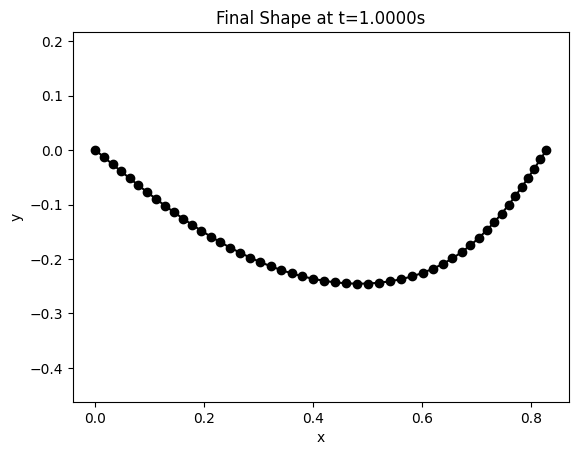

In [33]:
# Number of steps
Nsteps = round( totalTime / dt )

ctime = 0 # Current time

# Store the y-coordinate of the middle node, its velocity, and the angle
all_pos = np.zeros(Nsteps)
all_vel = np.zeros(Nsteps)
mid_angle = np.zeros(Nsteps)
max_y_displacement = np.zeros(Nsteps) # Store maximum vertical displacement

# Loop over the time steps
for timeStep in range(Nsteps): # Start from 0 to include initial state

  q_new, error = objfun(q0, u0, dt, tol, maximum_iter, m, mMat, EI, EA, W, C,
                        deltaL, free_index)
  if error < 0:
    print('Could not converge.')
    break

  u_new = (q_new - q0) / dt # New velocity


  ctime += dt # Update current time

  # Save information about the middle node
  all_pos[timeStep] = q_new[2*midNode-1] # y coordinate of middle node
  all_vel[timeStep] = u_new[2*midNode-1] # y velocity of middle node
  # Calculate turning angle at the middle node using dot product of adjacent segments
  vec1 = q_new[2*(midNode-1):2*midNode] - q_new[2*(midNode-2):2*(midNode-1)]
  vec2 = q_new[2*midNode:2*(midNode+1)] - q_new[2*(midNode-1):2*midNode]
  # Ensure vectors are 3D for cross product
  vec1_3d = np.append(vec1, 0)
  vec2_3d = np.append(vec2, 0)

  mid_angle[timeStep] =  np.degrees( np.arctan2(np.linalg.norm( np.cross(vec1_3d, vec2_3d)), np.dot(vec1_3d, vec2_3d)) )

  # Calculate and store maximum vertical displacement
  y_coords = q_new[1::2] # Get all y-coordinates
  max_y_displacement[timeStep] = np.min(y_coords) # Assuming downward displacement is negative


  q0 = q_new.copy() # New position becomes old position
  u0 = u_new.copy() # New velocity becomes old velocity

  # Plot
  if timeStep % plotStep == 0:
    x_arr = q_new[::2] # q[0], q[2], q[4]
    y_arr = q_new[1::2] # q[1], q[3], q[5]

    h1 = plt.figure(1)
    plt.clf() # Clear current figure
    plt.plot(x_arr, y_arr, 'ko-')
    plt.title(f't={ctime:.4f}s')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')


# Display the final shape after the loop
x_arr = q_new[::2]
y_arr = q_new[1::2]
h1 = plt.figure(1)
plt.clf()
plt.plot(x_arr, y_arr, 'ko-')
plt.title(f'Final Shape at t={ctime:.4f}s')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

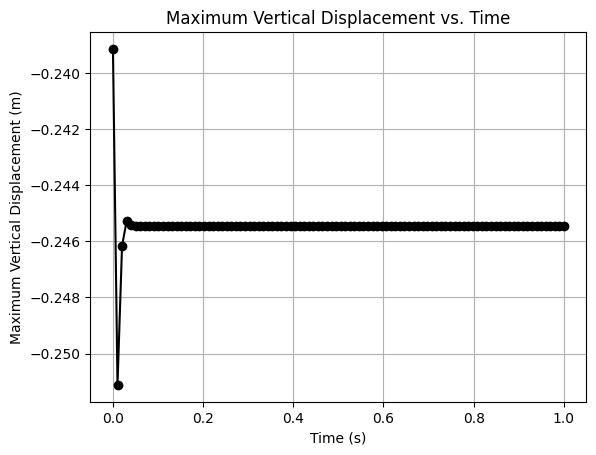

In [34]:
# Plot the maximum vertical displacement as a function of time
t_arr = np.linspace(0, totalTime, Nsteps)

plt.figure()
plt.plot(t_arr, max_y_displacement, 'ko-')
plt.xlabel('Time (s)')
plt.ylabel('Maximum Vertical Displacement (m)')
plt.title('Maximum Vertical Displacement vs. Time')
plt.grid(True)
plt.show()
if saveImage:
    plt.savefig('max_vertical_displacement.png')

In [35]:
# Theoretical calculation of maximum vertical displacement for a simply-supported beam with a point load
P = point_load  # Load in Newtons
l = RodLength  # Length of the beam in meters
d = load_position  # Distance from the left support to the load in meters
E = Y # Young's modulus in Pa
I = I # Moment of inertia in m^4

# Calculate c
c = min(d, l - d)

# Calculate theoretical ymax
ymax_theoretical = (P * c* (l**2 - c**2)**1.5) / (9 * np.sqrt(3) * E * I * l)

print(f"Theoretical maximum vertical displacement (ymax): {ymax_theoretical:.6f} m")

# Compare with the steady-state value from the simulation
# The steady-state value should be the last value in the max_y_displacement array
ymax_simulated = max_y_displacement[-1]

print(f"Simulated maximum vertical displacement (ymax): {-ymax_simulated:.6f} m")

# Calculate the percentage difference
percentage_difference = abs(ymax_theoretical + ymax_simulated) / abs(ymax_theoretical) * 100

print(f"Percentage difference between theoretical and simulated ymax: {percentage_difference:.2f}%")

Theoretical maximum vertical displacement (ymax): 0.380449 m
Simulated maximum vertical displacement (ymax): 0.245459 m
Percentage difference between theoretical and simulated ymax: 35.48%


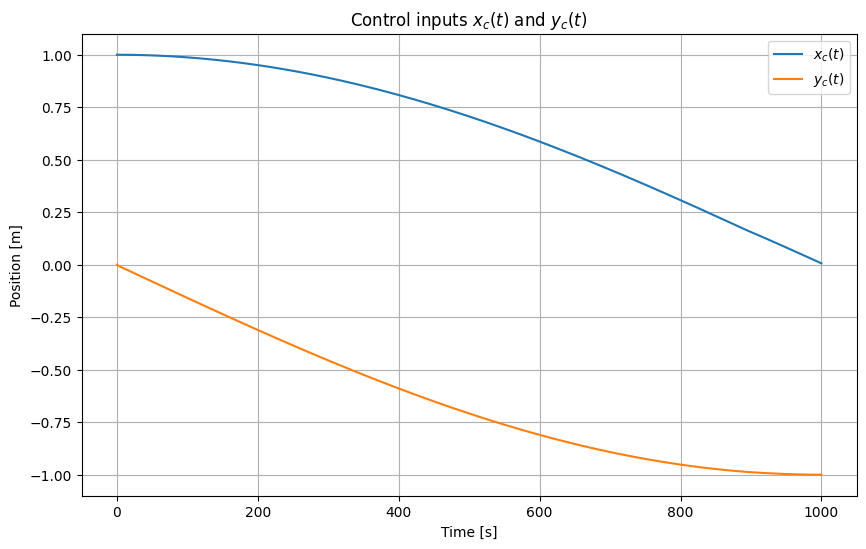

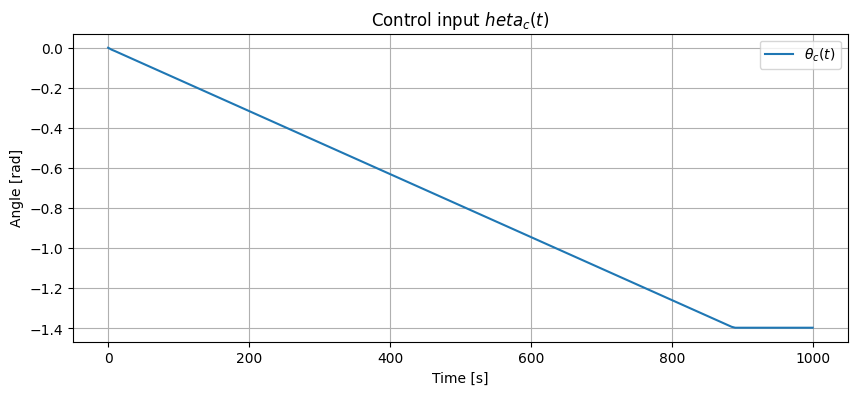

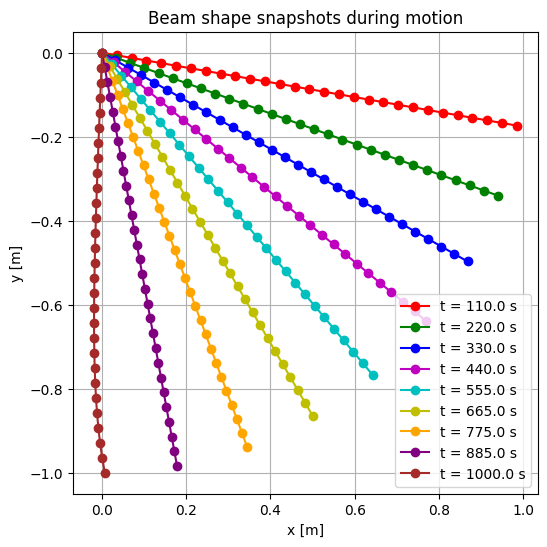

In [41]:

# HW3: Robotic control of an elastic beam (uses existing energy functions from HW2)

# Override discretization to use an odd number of nodes
nv = 29                      # number of nodes
ndof = 2 * nv
midNode = (nv + 1) // 2      # 1-based index of the middle node

# Physical / geometric parameters
RodLength = 1.0              # [m]
deltaL = RodLength / (nv - 1)

outer_radius = 0.013         # [m]
inner_radius = 0.011         # [m]
rho = 2700.0                 # [kg/m^3]
g = 9.81                     # [m/s^2]

# Material properties
Y = 70e9                     # [Pa] (70 GPa)
I = np.pi / 4.0 * (outer_radius**4 - inner_radius**4)
A = np.pi * (outer_radius**2 - inner_radius**2)
EI = Y * I
EA = Y * A

# Time integration parameters
totalTime = 1000.0
dt = 5
Nsteps = int(totalTime / dt)

maximum_iter = 200           # Newton iterations
tol = EI / RodLength**2 * 1e-9

# Nodal coordinates (initial straight configuration)
nodes = np.zeros((nv, 2))
for k in range(nv):
    nodes[k, 0] = k * deltaL
    nodes[k, 1] = 0.0

# Mass vector and matrix
m = np.zeros(ndof)
beam_mass_per_length = rho * A
node_mass = beam_mass_per_length * deltaL           # each node's lumped mass
for k in range(nv):
    m[2 * k]     = node_mass
    m[2 * k + 1] = node_mass
mMat = np.diag(m)

# Gravity load vector (acts in -y on every node)
Wg = np.zeros(ndof)
for k in range(nv):
    Wg[2 * k + 1] = -node_mass * g

# Viscous damping (you can tune "visc" if needed)
visc = 0.0
C = visc * np.eye(ndof)

# Initial conditions (straight beam)
q0 = np.zeros(ndof)
for k in range(nv):
    q0[2 * k]     = nodes[k, 0]
    q0[2 * k + 1] = nodes[k, 1]
u0 = np.zeros(ndof)


# Dirichlet boundary conditions: left end fixed, right end controlled
# Left end node index (0-based)
idx_left = 0
# Right end node index (0-based)
idx_N    = nv - 1
# Node just before the right end
idx_Nm1  = nv - 2

# Fixed DOFs (Dirichlet): (x1,y1), (x_{N-1},y_{N-1}), (x_N,y_N)
fixed_index = np.array([
    2*idx_left,     2*idx_left+1,
    2*idx_Nm1,      2*idx_Nm1+1,
    2*idx_N,        2*idx_N+1
], dtype=int)

all_DOFs = np.arange(ndof)
free_index = np.setdiff1d(all_DOFs, fixed_index)


# Target trajectory of the middle node
def target_middle_position(t, L):
    x_star = 0.5 * L * np.cos(0.5 * np.pi * t / totalTime)
    y_star = -0.5 * L * np.sin(0.5 * np.pi * t / totalTime)
    return x_star, y_star


# Control law:
def path_planner(x_mid, y_mid, x_star, y_star,
                 x_c_prev, y_c_prev,
                 L, Kp=0.5,
                 r_max_factor=1.2,
                 theta_max_deg=80.0):

    # Geometric guess: if beam were straight, end point is twice the middle
    x_geom = 2.0 * x_star
    y_geom = 2.0 * y_star

    # Tracking error of middle node
    ex = x_star - x_mid
    ey = y_star - y_mid

    # Proportional correction on end-effector position
    x_c = x_geom + Kp * ex
    y_c = y_geom + Kp * ey

    # Workspace saturation on radius
    r = np.sqrt(x_c**2 + y_c**2)
    r_max = r_max_factor * L
    if r > r_max and r > 1e-12:
        x_c *= r_max / r
        y_c *= r_max / r

    # Compute orientation from base to end
    theta_c = np.arctan2(y_c, x_c)

    # Joint angle saturation
    theta_max = np.deg2rad(theta_max_deg)
    theta_c = np.clip(theta_c, -theta_max, theta_max)

    return x_c, y_c, theta_c


def objfun_hw3(q_old, u_old, dt, tol, maximum_iter,
               m, mMat, EI, EA, Wg, C,
               deltaL, free_index, fixed_index, q_fixed_new):

    q_new = q_old.copy()
    # Start from the commanded boundary position
    q_new[fixed_index] = q_fixed_new[fixed_index]

    iter_count = 0
    error = tol * 10.0
    flag = 1

    while error > tol:
        # Enforce Dirichlet values inside the Newton loop
        q_new[fixed_index] = q_fixed_new[fixed_index]

        # Inertia term (backward Euler in velocity)
        F_inertia = m / dt * ((q_new - q_old) / dt - u_old)
        J_inertia = mMat / dt**2

        # Elastic forces (stretching + bending)
        Fs, Js = getFs(q_new, EA, deltaL)
        Fb, Jb = getFb(q_new, EI, deltaL)
        F_elastic = Fs + Fb
        J_elastic = Js + Jb

        # Damping
        Fv = -C @ ((q_new - q_old) / dt)
        Jv = -C / dt

        # Residual and Jacobian
        f = F_inertia - F_elastic - Fv - Wg
        J = J_inertia - J_elastic - Jv

        # Restrict to free DOFs
        f_free = f[free_index]
        J_free = J[np.ix_(free_index, free_index)]

        # Newton update
        dq_free = np.linalg.solve(J_free, f_free)
        q_new[free_index] -= dq_free

        # Convergence check
        error = np.linalg.norm(f_free)
        iter_count += 1
        if iter_count > maximum_iter:
            flag = -1
            print("Maximum number of iterations reached in objfun_hw3.")
            break

    return q_new, flag


# Time stepping loop
time_vec = np.linspace(0.0, totalTime, Nsteps+1)

# History arrays
xc_hist = np.zeros(Nsteps+1)
yc_hist = np.zeros(Nsteps+1)
theta_hist = np.zeros(Nsteps+1)

mid_x_hist = np.zeros(Nsteps+1)
mid_y_hist = np.zeros(Nsteps+1)
x_star_hist = np.zeros(Nsteps+1)
y_star_hist = np.zeros(Nsteps+1)

# Initial robot pose (from HW3: x_c(0)=L, y_c(0)=0, theta_c(0)=0)
x_c = RodLength
y_c = 0.0
theta_c = 0.0

xc_hist[0] = x_c
yc_hist[0] = y_c
theta_hist[0] = theta_c

# Snapshot storage for beam shapes
snapshot_times = np.linspace(0.0, totalTime, 10)
snapshot_indices = [int(t_snap / dt) for t_snap in snapshot_times]
snapshots = {}

# Main time stepping
ctime = 0.0
for step in range(1, Nsteps+1):
    ctime = step * dt

    # Desired middle-node position
    x_star, y_star = target_middle_position(ctime, RodLength)

    # Current middle-node position
    mid_x = q0[2 * (midNode-1)]
    mid_y = q0[2 * (midNode-1) + 1]

    # Store histories
    mid_x_hist[step-1] = mid_x
    mid_y_hist[step-1] = mid_y
    x_star_hist[step-1] = x_star
    y_star_hist[step-1] = y_star

    # Compute new control command
    x_c, y_c, theta_c = path_planner(
        mid_x, mid_y, x_star, y_star,
        x_c, y_c,
        RodLength
    )

    xc_hist[step] = x_c
    yc_hist[step] = y_c
    theta_hist[step] = theta_c

    # Build prescribed Dirichlet DOFs at t_{k+1}
    q_fixed_new = q0.copy()
    # left end clamped at origin
    q_fixed_new[2 * idx_left]     = 0.0
    q_fixed_new[2 * idx_left + 1] = 0.0
    # right end position
    q_fixed_new[2 * idx_N]     = x_c
    q_fixed_new[2 * idx_N + 1] = y_c
    # node N-1 one segment back along theta_c
    q_fixed_new[2 * idx_Nm1]     = x_c - deltaL * np.cos(theta_c)
    q_fixed_new[2 * idx_Nm1 + 1] = y_c - deltaL * np.sin(theta_c)

    # One implicit time step with moving BC
    q_new, flag = objfun_hw3(
        q0, u0, dt, tol, maximum_iter,
        m, mMat, EI, EA, Wg, C,
        deltaL, free_index, fixed_index, q_fixed_new
    )
    if flag < 0:
        print(f"Step {step}: Newton did not converge.")
        break

    # Update velocity and state
    u_new = (q_new - q0) / dt
    q0 = q_new.copy()
    u0 = u_new.copy()

    # Save snapshots
    if step in snapshot_indices:
        snapshots[step] = q_new.copy()

#Plot
plt.figure(figsize=(10, 6))
plt.plot(time_vec, xc_hist, label=r'$x_c(t)$')
plt.plot(time_vec, yc_hist, label=r'$y_c(t)$')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('Control inputs $x_c(t)$ and $y_c(t)$')
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 4))
plt.plot(time_vec, theta_hist, label=r'$\theta_c(t)$')
plt.xlabel('Time [s]')
plt.ylabel('Angle [rad]')
plt.title('Control input $\theta_c(t)$')
plt.legend()
plt.grid(True)


plt.figure(figsize=(6, 6))
colors = ['k', 'r', 'g', 'b', 'm', 'c', 'y', 'orange', 'purple', 'brown']
for i, step in enumerate(snapshot_indices):
    if step in snapshots:
        q_snap = snapshots[step]
        x_arr = q_snap[::2]
        y_arr = q_snap[1::2]
        plt.plot(x_arr, y_arr, marker='o', linestyle='-',
                 color=colors[i % len(colors)],
                 label=f't = {step*dt:.1f} s')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Beam shape snapshots during motion')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()